In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
sections = [
    "NDL-MTJ-01",
    "MTJ-AGC-01",
    "AGC-GWL-01",
    "GWL-JHS-01",
    "JHS-BINA-01",
    "BINA-BPL-01",
    "BPL-RTM-01",
    "RTM-VAD-01",
    "VAD-SRT-01",
    "SRT-MUM-01"
]

print("Number of sections:", len(sections))

Number of sections: 10


In [4]:
dates = pd.date_range(
    start="2022-01-01 00:00:00",
    end="2026-08-31 23:00:00",
    freq="h"
)

traffic = pd.MultiIndex.from_product(
    [dates, sections],
    names=["timestamp", "section_id"]
).to_frame(index=False)

print("Traffic dataset shape:", traffic.shape)
display(traffic.head())

Traffic dataset shape: (408960, 2)


,timestamp,section_id
0,2022-01-01,NDL-MTJ-01
1,2022-01-01,MTJ-AGC-01
2,2022-01-01,AGC-GWL-01
3,2022-01-01,GWL-JHS-01
4,2022-01-01,JHS-BINA-01


In [5]:
traffic["hour"] = traffic["timestamp"].dt.hour

traffic["day_of_week"] = (
    traffic["timestamp"].dt.dayofweek
)

traffic["month"] = (
    traffic["timestamp"].dt.month
)

traffic["is_weekend"] = (
    traffic["day_of_week"] >= 5
).astype(int)

traffic["is_peak_hour"] = (
    traffic["hour"].isin([7, 8, 9, 17, 18, 19, 20])
).astype(int)

In [6]:
morning_peak = np.exp(
    -((traffic["hour"] - 8) / 2.5) ** 2
)

evening_peak = np.exp(
    -((traffic["hour"] - 18) / 3) ** 2
)

day_factor = np.where(
    traffic["is_weekend"] == 1,
    0.80,
    1.00
)

season_factor = (
    1
    + 0.10 * np.sin(
        2 * np.pi * traffic["month"] / 12
    )
)

traffic["passenger_trains"] = (
    (
        3
        + 5 * morning_peak
        + 6 * evening_peak
    )
    * day_factor
    * season_factor
)

In [7]:
night_peak = np.exp(
    -((traffic["hour"] - 2) / 4) ** 2
)

traffic["freight_trains"] = (
    2
    + 5 * night_peak
    + 1.5 * traffic["is_peak_hour"]
)

In [8]:
section_factor = {
    section: np.random.uniform(0.8, 1.3)
    for section in sections
}

traffic["section_factor"] = (
    traffic["section_id"].map(section_factor)
)

traffic["passenger_trains"] *= (
    traffic["section_factor"]
)

traffic["freight_trains"] *= (
    traffic["section_factor"]
)

In [9]:
traffic["passenger_trains"] += np.random.normal(
    0,
    0.5,
    len(traffic)
)

traffic["freight_trains"] += np.random.normal(
    0,
    0.4,
    len(traffic)
)

traffic["passenger_trains"] = (
    traffic["passenger_trains"].clip(lower=0)
)

traffic["freight_trains"] = (
    traffic["freight_trains"].clip(lower=0)
)

traffic["total_trains"] = (
    traffic["passenger_trains"]
    + traffic["freight_trains"]
)

In [10]:
traffic["passenger_trains"] = (
    traffic["passenger_trains"].round().astype(int)
)

traffic["freight_trains"] = (
    traffic["freight_trains"].round().astype(int)
)

traffic["total_trains"] = (
    traffic["passenger_trains"]
    + traffic["freight_trains"]
)

In [11]:
display(
    traffic[
        [
            "timestamp",
            "section_id",
            "hour",
            "passenger_trains",
            "freight_trains",
            "total_trains"
        ]
    ].head(20)
)

,timestamp,section_id,hour,passenger_trains,freight_trains,total_trains
0,2022-01-01 00:00:00,NDL-MTJ-01,0,2,6,8
1,2022-01-01 00:00:00,MTJ-AGC-01,0,3,8,11
2,2022-01-01 00:00:00,AGC-GWL-01,0,3,7,10
3,2022-01-01 00:00:00,GWL-JHS-01,0,3,7,10
4,2022-01-01 00:00:00,JHS-BINA-01,0,2,5,7
5,2022-01-01 00:00:00,BINA-BPL-01,0,1,5,6
6,2022-01-01 00:00:00,BPL-RTM-01,0,1,4,5
7,2022-01-01 00:00:00,RTM-VAD-01,0,3,8,11
8,2022-01-01 00:00:00,VAD-SRT-01,0,2,7,9
9,2022-01-01 00:00:00,SRT-MUM-01,0,3,8,11


In [12]:
print(
    traffic[
        [
            "passenger_trains",
            "freight_trains",
            "total_trains"
        ]
    ].describe()
)

       passenger_trains  freight_trains   total_trains
count     408960.000000   408960.000000  408960.000000
mean           5.262060        3.855221       9.117280
std            2.303643        1.960528       2.877663
min            0.000000        0.000000       2.000000
25%            3.000000        2.000000       7.000000
50%            5.000000        3.000000       9.000000
75%            7.000000        5.000000      11.000000
max           14.000000       10.000000      19.000000


In [13]:
hourly_profile = (
    traffic
    .groupby("hour")
    .agg(
        passenger_trains=("passenger_trains", "mean"),
        freight_trains=("freight_trains", "mean"),
        total_trains=("total_trains", "mean")
    )
    .reset_index()
)

display(hourly_profile)

,hour,passenger_trains,freight_trains,total_trains
0,0,3.009800,6.249765,9.259566
1,1,3.014026,7.101643,10.115669
2,2,3.022418,7.412148,10.434566
3,3,3.105106,7.105106,10.210211
4,4,3.392723,6.250763,9.643486
5,5,4.197594,5.133979,9.331573
6,6,5.651702,4.068016,9.719718
7,7,7.285446,4.819131,12.104577
8,8,8.020540,4.262265,12.282805
9,9,7.286854,3.951174,11.238028


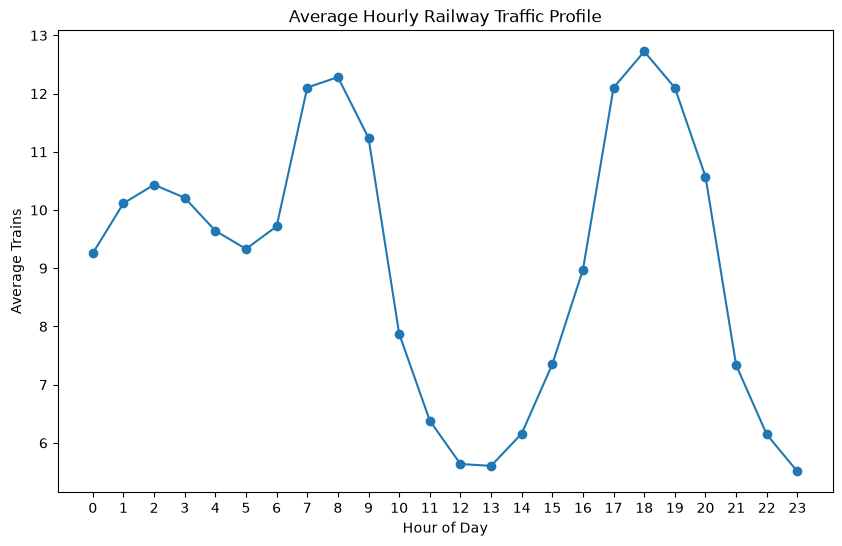

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_profile["hour"],
    hourly_profile["total_trains"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Trains")
plt.title("Average Hourly Railway Traffic Profile")
plt.xticks(range(24))

plt.show()

In [16]:
# Create an explicit date column first
traffic["date"] = traffic["timestamp"].dt.floor("D")

# Aggregate hourly traffic into daily traffic
daily_traffic = (
    traffic
    .groupby(
        ["date", "section_id"],
        as_index=False
    )
    .agg(
        passenger_trains=("passenger_trains", "sum"),
        freight_trains=("freight_trains", "sum"),
        total_trains=("total_trains", "sum")
    )
)

print("Daily traffic shape:", daily_traffic.shape)

display(daily_traffic.head())

Daily traffic shape: (17040, 5)


,date,section_id,passenger_trains,freight_trains,total_trains
0,2022-01-01,AGC-GWL-01,125,105,230
1,2022-01-01,BINA-BPL-01,90,76,166
2,2022-01-01,BPL-RTM-01,86,73,159
3,2022-01-01,GWL-JHS-01,119,97,216
4,2022-01-01,JHS-BINA-01,94,76,170


In [17]:
# Create an explicit date column first
traffic["date"] = traffic["timestamp"].dt.floor("D")

# Aggregate hourly traffic into daily traffic
daily_traffic = (
    traffic
    .groupby(
        ["date", "section_id"],
        as_index=False
    )
    .agg(
        passenger_trains=("passenger_trains", "sum"),
        freight_trains=("freight_trains", "sum"),
        total_trains=("total_trains", "sum")
    )
)

print("Daily traffic shape:", daily_traffic.shape)

display(daily_traffic.head())

Daily traffic shape: (17040, 5)


,date,section_id,passenger_trains,freight_trains,total_trains
0,2022-01-01,AGC-GWL-01,125,105,230
1,2022-01-01,BINA-BPL-01,90,76,166
2,2022-01-01,BPL-RTM-01,86,73,159
3,2022-01-01,GWL-JHS-01,119,97,216
4,2022-01-01,JHS-BINA-01,94,76,170


In [18]:
daily_traffic["day_of_week"] = (
    daily_traffic["date"].dt.dayofweek
)

daily_traffic["month"] = (
    daily_traffic["date"].dt.month
)

daily_traffic["day_of_year"] = (
    daily_traffic["date"].dt.dayofyear
)

print("Calendar features created.")

display(
    daily_traffic[
        [
            "date",
            "section_id",
            "day_of_week",
            "month",
            "day_of_year"
        ]
    ].head()
)

Calendar features created.


,date,section_id,day_of_week,month,day_of_year
0,2022-01-01,AGC-GWL-01,5,1,1
1,2022-01-01,BINA-BPL-01,5,1,1
2,2022-01-01,BPL-RTM-01,5,1,1
3,2022-01-01,GWL-JHS-01,5,1,1
4,2022-01-01,JHS-BINA-01,5,1,1


In [19]:
daily_traffic["lag_1"] = (
    daily_traffic
    .groupby("section_id")["total_trains"]
    .shift(1)
)

daily_traffic["lag_7"] = (
    daily_traffic
    .groupby("section_id")["total_trains"]
    .shift(7)
)

daily_traffic["rolling_7"] = (
    daily_traffic
    .groupby("section_id")["total_trains"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

print("Lag features created.")

display(
    daily_traffic[
        [
            "date",
            "section_id",
            "total_trains",
            "lag_1",
            "lag_7",
            "rolling_7"
        ]
    ].head(15)
)

Lag features created.


,date,section_id,total_trains,lag_1,lag_7,rolling_7
0,2022-01-01,AGC-GWL-01,230,NaN,NaN,NaN
1,2022-01-01,BINA-BPL-01,166,NaN,NaN,NaN
2,2022-01-01,BPL-RTM-01,159,NaN,NaN,NaN
3,2022-01-01,GWL-JHS-01,216,NaN,NaN,NaN
4,2022-01-01,JHS-BINA-01,170,NaN,NaN,NaN
5,2022-01-01,MTJ-AGC-01,245,NaN,NaN,NaN
6,2022-01-01,NDL-MTJ-01,190,NaN,NaN,NaN
7,2022-01-01,RTM-VAD-01,244,NaN,NaN,NaN
8,2022-01-01,SRT-MUM-01,224,NaN,NaN,NaN
9,2022-01-01,VAD-SRT-01,209,NaN,NaN,NaN


In [20]:
forecast_data = daily_traffic.dropna(
    subset=[
        "lag_1",
        "lag_7",
        "rolling_7"
    ]
).copy()

print(
    "Forecasting dataset shape:",
    forecast_data.shape
)

Forecasting dataset shape: (16970, 11)


In [21]:
split_date = pd.Timestamp("2026-01-01")

traffic_train = forecast_data[
    forecast_data["date"] < split_date
].copy()

traffic_test = forecast_data[
    forecast_data["date"] >= split_date
].copy()

print("Training rows:", len(traffic_train))
print("Testing rows:", len(traffic_test))

print(
    "Training range:",
    traffic_train["date"].min(),
    "to",
    traffic_train["date"].max()
)

print(
    "Testing range:",
    traffic_test["date"].min(),
    "to",
    traffic_test["date"].max()
)

Training rows: 14540
Testing rows: 2430
Training range: 2022-01-08 00:00:00 to 2025-12-31 00:00:00
Testing range: 2026-01-01 00:00:00 to 2026-08-31 00:00:00


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast_features = [
    "day_of_week",
    "month",
    "day_of_year",
    "lag_1",
    "lag_7",
    "rolling_7"
]

forecast_target = "total_trains"

X_train = traffic_train[forecast_features]
y_train = traffic_train[forecast_target]

X_test = traffic_test[forecast_features]
y_test = traffic_test[forecast_target]

traffic_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

traffic_model.fit(
    X_train,
    y_train
)

traffic_predictions = traffic_model.predict(
    X_test
)

print("Traffic forecasting model trained successfully.")

Traffic forecasting model trained successfully.


In [23]:
traffic_mae = mean_absolute_error(
    y_test,
    traffic_predictions
)

traffic_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        traffic_predictions
    )
)

print("Traffic Forecast Performance")
print("----------------------------")
print("MAE :", round(traffic_mae, 2))
print("RMSE:", round(traffic_rmse, 2))

Traffic Forecast Performance
----------------------------
MAE : 3.26
RMSE: 4.07


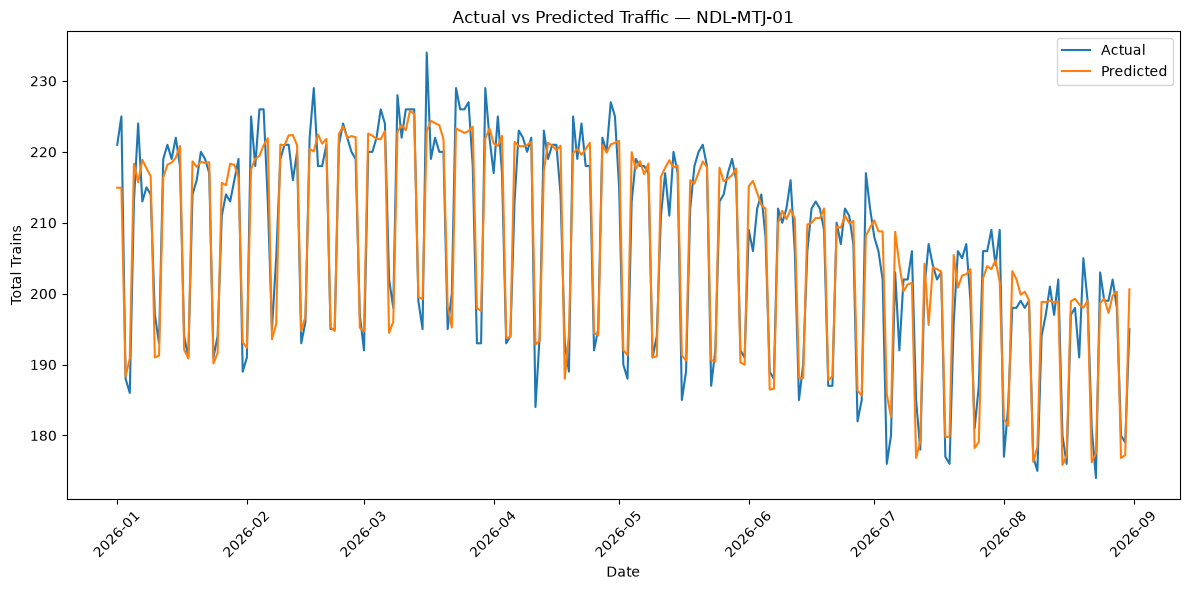

In [24]:
traffic_plot = traffic_test[
    ["date", "section_id", "total_trains"]
].copy()

traffic_plot["predicted_total_trains"] = (
    traffic_predictions
)

# Plot one representative section
plot_section = sections[0]

section_plot = traffic_plot[
    traffic_plot["section_id"] == plot_section
].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    section_plot["date"],
    section_plot["total_trains"],
    label="Actual"
)

plt.plot(
    section_plot["date"],
    section_plot["predicted_total_trains"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Total Trains")
plt.title(
    f"Actual vs Predicted Traffic — {plot_section}"
)

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
traffic_importance = pd.DataFrame({
    "feature": forecast_features,
    "importance": traffic_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(traffic_importance)

,feature,importance
4,lag_7,0.972109
5,rolling_7,0.020490
2,day_of_year,0.003254
0,day_of_week,0.002246
3,lag_1,0.001156
1,month,0.000743


In [26]:
traffic_results = traffic_test[
    [
        "date",
        "section_id",
        "total_trains",
        "passenger_trains",
        "freight_trains",
        "lag_1",
        "lag_7",
        "rolling_7"
    ]
].copy()

traffic_results["predicted_total_trains"] = (
    traffic_predictions
)

traffic_results["forecast_error"] = (
    traffic_results["predicted_total_trains"]
    - traffic_results["total_trains"]
)

display(
    traffic_results.head(20)
)

,date,section_id,total_trains,passenger_trains,freight_trains,lag_1,lag_7,rolling_7,predicted_total_trains,forecast_error
14610,2026-01-01,AGC-GWL-01,258,153,105,253.0,249.0,240.285714,253.589540,-4.410460
14611,2026-01-01,BINA-BPL-01,197,121,76,192.0,184.0,181.142857,191.638284,-5.361716
14612,2026-01-01,BPL-RTM-01,185,112,73,178.0,181.0,171.142857,182.724145,-2.275855
14613,2026-01-01,GWL-JHS-01,240,145,95,233.0,238.0,226.428571,238.287108,-1.712892
14614,2026-01-01,JHS-BINA-01,199,121,78,185.0,186.0,178.285714,188.939437,-10.060563
14615,2026-01-01,MTJ-AGC-01,280,170,110,273.0,276.0,264.142857,278.750500,-1.249500
14616,2026-01-01,NDL-MTJ-01,221,133,88,214.0,220.0,206.571429,214.943172,-6.056828
14617,2026-01-01,RTM-VAD-01,269,162,107,259.0,260.0,255.142857,269.859950,0.859950
14618,2026-01-01,SRT-MUM-01,253,152,101,245.0,244.0,238.571429,249.615617,-3.384383
14619,2026-01-01,VAD-SRT-01,240,145,95,239.0,246.0,227.428571,237.456859,-2.543141


In [27]:
traffic_results.to_csv(
    "../data/predictions/traffic_forecast_predictions.csv",
    index=False
)

print(
    "Saved:",
    "../data/predictions/traffic_forecast_predictions.csv"
)

Saved: ../data/predictions/traffic_forecast_predictions.csv
